# Clustering text lines by indentation and width

This notebook demonstrates `archival_structures.analysis.line_clustering`: extracting
per-line spatial features (left indentation, width, height) from a set of PageXML scans, and
clustering them with two different approaches:

1. `cluster_lines` -- HDBSCAN over the feature vectors, considering indentation and width jointly.
2. `cluster_lines_by_peaks` -- a lighter-weight alternative that buckets indentation into
   per-scan peaks (good when you mainly care about indentation levels, not width).

The resulting cluster labels are a vocabulary of recurring line types (e.g. "body text", "a short
indented line") that `sequence_patterns.py` can build on.

This uses `NL-HaNA_2.10.50_1`, one of the book-of-openings inventory numbers, and -- crucially --
**splits each two-page opening into single pages first** with
`archival_structures.analysis.opening_detection.split_inventory_into_pages`. Clustering directly
on un-split two-page scans conflates the left and right page's columns into one absolute
coordinate frame, where they don't actually share a coordinate system: each page's own left
margin is what indentation should be measured relative to. Splitting first means a "body text"
cluster can be shared by both the verso and recto sides of an opening, which we check for below.

In [7]:
from pathlib import Path

from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, split_inventory_into_pages, get_opening_features,
)
from archival_structures.analysis.line_clustering import (
    extract_corpus_line_features, cluster_lines, cluster_lines_by_peaks,
)

INSTITUTE = 'NL-HaNA'
ARCHIVE = 'NL-HaNA_2.10.50'
INVENTORY_NUM = 'NL-HaNA_2.10.50_1'
PAGEXML_DIR = Path('../../data/PageXML') / INSTITUTE / ARCHIVE / INVENTORY_NUM
THUMB_DIR = Path('../../data/thumbs') / INSTITUTE / ARCHIVE / INVENTORY_NUM

assert PAGEXML_DIR.exists(), PAGEXML_DIR
assert THUMB_DIR.exists(), THUMB_DIR

## Load a sample of scans, split openings into pages, and extract line features

We use the first 80 scans of the inventory number -- enough to get a feel for the recurring line
types without waiting too long. Increase this once you're happy with the results.

In [8]:
xml_paths = sorted(PAGEXML_DIR.glob('*.xml'))[:80]
scans = [pagexml_parser.parse_pagexml_file(str(xml_path)) for xml_path in xml_paths]
scans_by_id = {scan.id: scan for scan in scans}
print(f"loaded {len(scans)} scans")

structure = classify_inventory_structure(scans)
print(f"inventory structure: {structure.structure_type} {structure.type_counts}")

pages = split_inventory_into_pages(scans, structure=structure)
page_by_id = {page.id: page for page in pages}
print(f"{len(scans)} scans -> {len(pages)} pages")

line_df = extract_corpus_line_features(pages)
print(f"{len(line_df)} lines total")
line_df.head()

loaded 80 scans
inventory structure: book_of_openings {'opening': 58, 'single_page': 21, 'odd_shaped': 1}
80 scans -> 138 pages
8333 lines total


/Users/marijnkoolen/Code/Huygens/archival-structures/archival_structures/analysis/line_clustering.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([extract_line_features(scan) for scan in scans], ignore_index=True)


,scan_id,line_id,left,width,height,left_norm,width_norm,height_norm
0,NL-HaNA_2.10.50_1_0001.jpg,line_9479897f-a56c-40ff-ad6e-1b75d7614b6a,322,129,155,0.075269,0.030154,0.027193
1,NL-HaNA_2.10.50_1_0001.jpg,ad9df89c-f3b4-4ed2-b589-fde35136c911,344,191,198,0.080411,0.044647,0.034737
2,NL-HaNA_2.10.50_1_0001.jpg,c3e5d022-ca1d-4578-80d7-604035939e64,407,164,182,0.095138,0.038336,0.031930
3,NL-HaNA_2.10.50_1_0001.jpg,line_2de5c5bd-20bd-454d-a59b-d052b0a95ab7,583,19,90,0.136279,0.004441,0.015789
4,NL-HaNA_2.10.50_1_0001.jpg,db8d124a-7f5b-4517-9e38-acd581d514fd,289,284,171,0.067555,0.066386,0.030000


## Approach 1: HDBSCAN over (left_norm, width_norm)

`min_cluster_size` controls how many lines must share a feature region for it to count as a
cluster rather than noise (label `-1`).

In [9]:
line_df['cluster'] = cluster_lines(line_df, features=('left_norm', 'width_norm'), min_cluster_size=15)

print("cluster sizes:")
print(line_df['cluster'].value_counts().sort_index())
print("\nper-cluster (left_norm, width_norm) summary -- tight std means a clean, consistent cluster:")
line_df.groupby('cluster')[['left_norm', 'width_norm']].agg(['mean', 'std', 'count'])

cluster sizes:
cluster
-1     2136
 0      104
 1      220
 2      165
 3      571
 4       28
 5      736
 6      299
 7      316
 8       21
 9      157
 10     397
 11      75
 12      16
 13      21
 14      19
 15      24
 16     200
 17     203
 18      87
 19      20
 20     469
 21     200
 22     170
 23      20
 24      20
 25     203
 26     126
 27     346
 28     812
 29      15
 30      32
 31     105
Name: count, dtype: int64

per-cluster (left_norm, width_norm) summary -- tight std means a clean, consistent cluster:


left_norm                 width_norm                
             mean       std count       mean       std count
cluster                                                     
-1       0.435129  0.224592  2136   0.141124  0.106172  2136
 0       0.877693  0.014715   104   0.023008  0.016035   104
 1       0.752158  0.020543   220   0.032810  0.018712   220
 2       0.747394  0.005456   165   0.150496  0.011168   165
 3       0.022061  0.012028   571   0.196376  0.027669   571
 4       0.784333  0.004285    28   0.081613  0.002770    28
 5       0.789915  0.013273   736   0.167775  0.026629   736
 6       0.108709  0.012745   299   0.093888  0.051554   299
 7       0.397073  0.009090   316   0.080338  0.016283   316
 8       0.453942  0.006420    21   0.035181  0.007963    21
 9       0.184728  0.017939   157   0.360672  0.031540   157
 10      0.495902  0.013800   397   0.296216  0.023442   397
 11      0.178687  0.012269    75   0.037274  0.010986    75
 12      0.664026  0.006495    16   0.018473  0.005137    16
 13      0.503870  0.005352    21   0.024596  0.005705    21
 14      0.576822  0.004110    19   0.250336  0.007570    19
 15      0.491298  0.003388    24   0.055903  0.007043    24
 16      0.510373  0.005548   200   0.098093  0.013868   200
 17      0.626829  0.005581   203   0.108576  0.010335   203
 18      0.586145  0.010242    87   0.116993  0.003079    87
 19      0.580739  0.004846    20   0.094045  0.005937    20
 20      0.579510  0.012079   469   0.067907  0.003756   469
 21      0.578448  0.012457   200   0.026253  0.001681   200
 22      0.584101  0.010792   170   0.045192  0.003871   170
 23      0.331617  0.007029    20   0.037768  0.003519    20
 24      0.244863  0.005737    20   0.095163  0.005583    20
 25      0.582244  0.010522   203   0.193582  0.008860   203
 26      0.574065  0.007717   126   0.160993  0.006466   126
 27      0.292275  0.006421   346   0.026778  0.009072   346
 28      0.250803  0.009593   812   0.217075  0.026613   812
 29      0.282184  0.004740    15   0.146817  0.003289    15
 30      0.294009  0.003633    32   0.061884  0.006086    32
 31      0.292454  0.005163   105   0.093779  0.006053   105

### Check that splitting actually paid off

If splitting into pages worked as intended, the same cluster should show up on both verso and
recto pages (a "body text" line looks the same regardless of which side of the opening it's
on) -- rather than verso and recto each getting their own separate clusters purely because they
used to sit at different absolute x-positions on the original two-page scan.

In [10]:
def page_side(scan_id: str) -> str:
    if scan_id.endswith('-verso'):
        return 'verso'
    if scan_id.endswith('-recto'):
        return 'recto'
    return 'single_page'


line_df['side'] = line_df['scan_id'].apply(page_side)
sides_per_cluster = line_df[line_df['cluster'] != -1].groupby('cluster')['side'].nunique()
n_shared = (sides_per_cluster > 1).sum()
print(f"{n_shared} / {len(sides_per_cluster)} clusters contain lines from more than one page side "
     f"(verso and/or recto and/or single-page covers)")

30 / 32 clusters contain lines from more than one page side (verso and/or recto and/or single-page covers)


### Visualise the clusters

Each line is drawn in the colour of its cluster (grey = noise, `-1`), so you can sanity-check
that clusters correspond to visually distinct line types, on top of the actual scan thumbnail
(`data/thumbs/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1`). A split page's thumbnail is the
relevant half of its original opening's thumbnail, cropped at the same `separation_point` used
to split the PageXML (recomputed via `get_opening_features`, since the split itself doesn't keep
it around). A verso/recto pair is shown side by side, since that's exactly the case splitting
was meant to handle well.

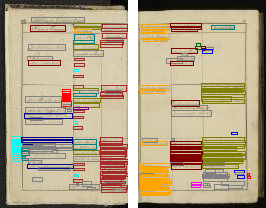

In [11]:
PALETTE = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta',
          'darkgreen', 'darkblue', 'olive', 'teal', 'navy', 'maroon', 'gold']


def cluster_color(cluster_id: int) -> str:
    return 'gray' if cluster_id == -1 else PALETTE[cluster_id % len(PALETTE)]


def original_scan_id(page_id: str) -> str:
    for suffix in ('-verso', '-recto'):
        if page_id.endswith(suffix):
            return page_id[:-len(suffix)]
    return page_id


def page_thumbnail(page) -> Image.Image:
    """Load `page`'s thumbnail. For a split verso/recto page this is the corresponding half of
    its original opening's thumbnail, cropped at the same separation point used to split the
    PageXML (recomputed here since `split_inventory_into_pages` doesn't keep it around)."""
    scan_id = original_scan_id(page.id)
    image = Image.open(THUMB_DIR / scan_id).convert('RGB')
    if page.id == scan_id:
        return image
    scan = scans_by_id[scan_id]
    scale = image.width / scan.coords.width
    sep_x = round(get_opening_features(scan).separation_point.x * scale)
    return image.crop((0, 0, sep_x, image.height)) if page.id.endswith('-verso') \
        else image.crop((sep_x, 0, image.width, image.height))


def draw_clustered_lines(page, line_df, cluster_col: str = 'cluster') -> Image.Image:
    """Draw each of `page`'s lines, coloured by its cluster label, on top of its thumbnail."""
    image = page_thumbnail(page).copy()
    scale = image.width / page.coords.width
    draw = ImageDraw.Draw(image)
    page_lines = line_df[line_df['scan_id'] == page.id].set_index('line_id')
    for line in page.get_lines():
        if line.id not in page_lines.index:
            continue
        cluster_id = page_lines.loc[line.id, cluster_col]
        x, y = line.coords.left * scale, line.coords.top * scale
        w, h = line.coords.width * scale, line.coords.height * scale
        draw.rectangle([x, y, x + w, y + h], outline=cluster_color(cluster_id), width=1)
    return image


# a verso/recto pair that both have a reasonable number of lines, for a meaningful comparison
example_verso = next(page for page in pages if page.id.endswith('-verso') and len(page.get_lines()) > 5)
example_recto = page_by_id[example_verso.id.replace('-verso', '-recto')]

verso_image = draw_clustered_lines(example_verso, line_df)
recto_image = draw_clustered_lines(example_recto, line_df)
side_by_side = Image.new('RGB', (verso_image.width + recto_image.width + 10,
                                 max(verso_image.height, recto_image.height)), 'white')
side_by_side.paste(verso_image, (0, 0))
side_by_side.paste(recto_image, (verso_image.width + 10, 0))
side_by_side

## Approach 2: peak-based indentation clustering

`cluster_lines_by_peaks` finds indentation peaks separately per scan (via `group_cols`), and
labels each line by which peak's range its `left` value falls into. `width_bin_size` is in the
same units as `cluster_col` -- here raw pixels, so a pixel-scale bin size (e.g. 50).

In [12]:
line_df['peak_cluster'] = cluster_lines_by_peaks(line_df, cluster_col='left', group_cols='scan_id',
                                                 width_bin_size=50, min_prominence=2)

print("most common peak-based clusters:")
line_df['peak_cluster'].value_counts().head(10)

most common peak-based clusters:


peak_cluster
left_NA           8268
left_1416_1516      27
left_1710_1810      18
left_1673_1773      12
left_2783_2883       8
Name: count, dtype: int64

Unlike HDBSCAN's clusters, peak-based cluster labels are scan-relative (a `left_645_745` cluster
on one scan isn't necessarily the same column position on another scan with a different gutter
position) -- a tradeoff for being cheaper and not needing a global `min_cluster_size`.